# Fair-RAG Exploratory Stats Notebook

This notebook is separate from the experiment runner and focuses on per-query exploratory analysis.

Scope:
- Build a canonical per-query analysis table from completed runs
- Normalize EU, EE-R, EE-D, and ILD consistently across each LaMP task
- Inspect whether diversity magnitude appears to help or hurt utility
- Check whether EE-R is positively related to utility
- Fit a small tree-like estimator to test whether these metrics carry predictive signal
- Evaluate whether BM25, SPLADE, and Contriever are better than random as binary relevance predictors

In [2]:
import json
import math
import os
import random
from dataclasses import dataclass, field
from math import comb
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from framework import build_query_metric_rows, list_run_dirs
from analysis import (
    find_completed_run_dirs,
    safe_div,
    normalize_query_rows,
    bootstrap_ci,
    assign_quantile_bins,
    summarize_binned_metric,
    middle_vs_tail_summary,
    add_quantile_trend,
    weighted_mean,
    load_relevance_mapping,
    load_retrieval_scores,
)

try:
    from sklearn.metrics import accuracy_score, roc_auc_score
    from sklearn.model_selection import StratifiedKFold
    from sklearn.tree import DecisionTreeClassifier, export_text
    HAVE_SKLEARN = True
except Exception:
    HAVE_SKLEARN = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

print(f"numpy={np.__version__}")
print(f"pandas={pd.__version__}")
print(f"matplotlib={plt.matplotlib.__version__}")
print(f"sklearn_available={HAVE_SKLEARN}")

/Users/asimk/Code/Fair-RAG/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0504 10:44:28.682000 26261 .venv/lib/python3.11/site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


numpy=2.4.4
pandas=3.0.1
matplotlib=3.10.8
sklearn_available=True


In [3]:
@dataclass(frozen=True)
class AnalysisConfig:
    repo_root: str
    dataset_type: str = "lamp"
    lamp_split_type: str = "user"
    generator_name: str = "flanT5Small"
    top_k: int = 5
    rankers: tuple[str, ...] = ("bm25", "splade", "contriever")
    include_gold_reference: bool = True
    ild_bins: int = 10
    bootstrap_rounds: int = 300
    permutation_rounds: int = 200
    tree_target_quantile: float = 0.5
    random_seed: int = 42


REPO_ROOT = os.path.abspath(os.getcwd())
CFG = AnalysisConfig(repo_root=REPO_ROOT)
RUNS_ROOT = Path(CFG.repo_root) / "experiment_runs"
LABELS_ROOT = Path(CFG.repo_root) / "data" / f"lamp_utility_labels_{CFG.generator_name}"
RETRIEVAL_ROOT = Path(CFG.repo_root) / "retrieval" / "retrieval_results" / CFG.generator_name

print(CFG)
print(f"RUNS_ROOT={RUNS_ROOT}")
print(f"LABELS_ROOT={LABELS_ROOT}")
print(f"RETRIEVAL_ROOT={RETRIEVAL_ROOT}")

AnalysisConfig(repo_root='/Users/asimk/Code/Fair-RAG', dataset_type='lamp', lamp_split_type='user', generator_name='flanT5Small', top_k=5, rankers=('bm25', 'splade', 'contriever'), include_gold_reference=True, ild_bins=10, bootstrap_rounds=300, permutation_rounds=200, tree_target_quantile=0.5, random_seed=42)
RUNS_ROOT=/Users/asimk/Code/Fair-RAG/experiment_runs
LABELS_ROOT=/Users/asimk/Code/Fair-RAG/data/lamp_utility_labels_flanT5Small
RETRIEVAL_ROOT=/Users/asimk/Code/Fair-RAG/retrieval/retrieval_results/flanT5Small


In [5]:
def permutation_spearman(x, y, rounds=None, seed=None):
    frame = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(frame) < 3:
        return np.nan, np.nan

    observed = float(frame["x"].corr(frame["y"], method="spearman"))
    rounds = rounds or CFG.permutation_rounds
    rng = np.random.default_rng(CFG.random_seed if seed is None else seed)
    permuted = []
    y_values = frame["y"].to_numpy()
    for _ in range(rounds):
        shuffled = rng.permutation(y_values)
        permuted.append(float(pd.Series(frame["x"]).corr(pd.Series(shuffled), method="spearman")))
    p_value = (1 + sum(abs(v) >= abs(observed) for v in permuted)) / (rounds + 1)
    return observed, p_value


def _roc_auc_from_scores(labels, scores):
    frame = pd.DataFrame({"label": labels, "score": scores}).dropna()
    if frame.empty:
        raise ValueError("AUC requires non-empty labels and scores")
    if frame["label"].nunique() != 2:
        raise ValueError("AUC requires both positive and negative labels")

    frame["rank"] = frame["score"].rank(method="average")
    pos = frame["label"] == 1
    n_pos = int(pos.sum())
    n_neg = int((~pos).sum())
    rank_sum_pos = float(frame.loc[pos, "rank"].sum())
    return (rank_sum_pos - (n_pos * (n_pos + 1) / 2.0)) / (n_pos * n_neg)


def _exact_sign_test_greater(values, threshold=0.5):
    clean = [float(v) for v in values if not pd.isna(v) and float(v) != threshold]
    n = len(clean)
    if n == 0:
        return np.nan
    wins = sum(v > threshold for v in clean)
    return sum(comb(n, k) for k in range(wins, n + 1)) / (2 ** n)


def _fit_best_stump(train_df: pd.DataFrame, feature_cols: list[str], target_col: str):
    best = None
    y = train_df[target_col].astype(int)
    for feature in feature_cols:
        values = sorted(train_df[feature].dropna().unique())
        if len(values) < 2:
            continue
        thresholds = [(a + b) / 2.0 for a, b in zip(values[:-1], values[1:])]
        if len(thresholds) > 25:
            idx = np.linspace(0, len(thresholds) - 1, 25, dtype=int)
            thresholds = [thresholds[i] for i in idx]
        for threshold in thresholds:
            left_rate = y[train_df[feature] <= threshold].mean() if (train_df[feature] <= threshold).any() else y.mean()
            right_rate = y[train_df[feature] > threshold].mean() if (train_df[feature] > threshold).any() else y.mean()
            probs = np.where(train_df[feature] <= threshold, left_rate, right_rate)
            preds = (probs >= 0.5).astype(int)
            acc = float((preds == y).mean())
            candidate = {
                "feature": feature,
                "threshold": float(threshold),
                "left_rate": float(left_rate),
                "right_rate": float(right_rate),
                "accuracy": acc,
            }
            if best is None or candidate["accuracy"] > best["accuracy"]:
                best = candidate
    return best


def _apply_stump(model: dict, df: pd.DataFrame):
    probs = np.where(df[model["feature"]] <= model["threshold"], model["left_rate"], model["right_rate"])
    preds = (probs >= 0.5).astype(int)
    return preds, probs


def evaluate_tree_like_model(df: pd.DataFrame, feature_cols: list[str], target_col: str):
    model_df = df.dropna(subset=feature_cols + [target_col]).copy()
    if model_df.empty or model_df[target_col].nunique() < 2:
        raise ValueError("Tree evaluation requires at least two classes with non-null features")

    if HAVE_SKLEARN:
        splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=CFG.random_seed)
        X = model_df[feature_cols].to_numpy()
        y = model_df[target_col].astype(int).to_numpy()

        def _cv_score(labels):
            aucs = []
            accs = []
            for train_idx, test_idx in splitter.split(X, labels):
                tree = DecisionTreeClassifier(max_depth=3, random_state=CFG.random_seed)
                tree.fit(X[train_idx], labels[train_idx])
                probs = tree.predict_proba(X[test_idx])[:, 1]
                preds = (probs >= 0.5).astype(int)
                accs.append(float(accuracy_score(labels[test_idx], preds)))
                aucs.append(float(roc_auc_score(labels[test_idx], probs)))
            return float(np.mean(accs)), float(np.mean(aucs))

        observed_acc, observed_auc = _cv_score(y)
        rng = np.random.default_rng(CFG.random_seed)
        perm_aucs = []
        for _ in range(CFG.permutation_rounds):
            shuffled = rng.permutation(y)
            _, perm_auc = _cv_score(shuffled)
            perm_aucs.append(perm_auc)
        permutation_p = (1 + sum(v >= observed_auc for v in perm_aucs)) / (CFG.permutation_rounds + 1)

        final_tree = DecisionTreeClassifier(max_depth=3, random_state=CFG.random_seed)
        final_tree.fit(X, y)
        structure = export_text(final_tree, feature_names=feature_cols)
        baseline_rate = max(model_df[target_col].mean(), 1.0 - model_df[target_col].mean())
        return {
            "mode": "sklearn_tree",
            "accuracy": observed_acc,
            "auc": observed_auc,
            "baseline_accuracy": float(baseline_rate),
            "permutation_p_value": float(permutation_p),
            "model_text": structure,
        }

    shuffled = model_df.sample(frac=1.0, random_state=CFG.random_seed).reset_index(drop=True)
    fold_ids = np.arange(len(shuffled)) % 5
    accs = []
    aucs = []
    for fold in range(5):
        train_df = shuffled[fold_ids != fold]
        test_df = shuffled[fold_ids == fold]
        stump = _fit_best_stump(train_df, feature_cols, target_col)
        preds, probs = _apply_stump(stump, test_df)
        accs.append(float((preds == test_df[target_col].astype(int)).mean()))
        aucs.append(float(_roc_auc_from_scores(test_df[target_col].astype(int), probs)))

    observed_acc = float(np.mean(accs))
    observed_auc = float(np.mean(aucs))
    baseline_rate = max(model_df[target_col].mean(), 1.0 - model_df[target_col].mean())

    rng = np.random.default_rng(CFG.random_seed)
    perm_aucs = []
    for _ in range(CFG.permutation_rounds):
        shuffled_target = model_df[target_col].sample(frac=1.0, replace=False, random_state=int(rng.integers(0, 10_000_000))).reset_index(drop=True)
        perm_df = model_df.copy().reset_index(drop=True)
        perm_df[target_col] = shuffled_target
        perm_fold_accs = []
        perm_fold_aucs = []
        shuffled_perm = perm_df.sample(frac=1.0, random_state=CFG.random_seed).reset_index(drop=True)
        perm_fold_ids = np.arange(len(shuffled_perm)) % 5
        for fold in range(5):
            train_df = shuffled_perm[perm_fold_ids != fold]
            test_df = shuffled_perm[perm_fold_ids == fold]
            stump = _fit_best_stump(train_df, feature_cols, target_col)
            preds, probs = _apply_stump(stump, test_df)
            perm_fold_accs.append(float((preds == test_df[target_col].astype(int)).mean()))
            perm_fold_aucs.append(float(_roc_auc_from_scores(test_df[target_col].astype(int), probs)))
        perm_aucs.append(float(np.mean(perm_fold_aucs)))

    permutation_p = (1 + sum(v >= observed_auc for v in perm_aucs)) / (CFG.permutation_rounds + 1)
    final_stump = _fit_best_stump(model_df, feature_cols, target_col)
    return {
        "mode": "custom_stump",
        "accuracy": observed_acc,
        "auc": observed_auc,
        "baseline_accuracy": float(baseline_rate),
        "permutation_p_value": float(permutation_p),
        "model_text": str(final_stump),
    }

In [6]:
selected_run_dirs = find_completed_run_dirs(
    dataset_type=CFG.dataset_type,
    lamp_split_type=CFG.lamp_split_type,
    generator_name=CFG.generator_name,
    top_k=CFG.top_k,
    rankers=list(CFG.rankers),
)
if CFG.include_gold_reference:
    gold_dirs = find_completed_run_dirs(
        dataset_type=CFG.dataset_type,
        lamp_split_type=CFG.lamp_split_type,
        generator_name=CFG.generator_name,
        top_k=CFG.top_k,
        rankers=["gold"],
        rerank_method="deterministic",
    )
    selected_run_dirs = sorted(set(selected_run_dirs) | set(gold_dirs))
query_rows = build_query_metric_rows(selected_run_dirs)
query_df = pd.DataFrame(query_rows)

if query_df.empty:
    raise RuntimeError("No matching completed runs were found for the current configuration.")

normalized_df = normalize_query_rows(query_df)
analysis_df = normalized_df[normalized_df["ranker"].isin(CFG.rankers)].copy()
analysis_df["target_high_eu"] = analysis_df.groupby("lamp_num")["expected_utility_norm"].transform(
    lambda s: (s >= s.quantile(CFG.tree_target_quantile)).astype(int)
 )

print(f"Selected run dirs: {len(selected_run_dirs)}")
print(f"Query rows loaded: {len(query_df)}")
print(f"Analysis rows (non-gold): {len(analysis_df)}")
display(
    analysis_df[[
        "lamp_num",
        "generator_name",
        "ranker",
        "rerank_method",
        "pl_alpha",
        "mmr_lambda",
        "ee_relevance_norm",
        "ee_disparity_norm",
        "expected_utility_norm",
        "avg_ild_jaccard_norm",
    ]].head(10)
 )

Selected run dirs: 230
Query rows loaded: 104911
Analysis rows (non-gold): 100690


,lamp_num,generator_name,ranker,rerank_method,pl_alpha,mmr_lambda,ee_relevance_norm,ee_disparity_norm,expected_utility_norm,avg_ild_jaccard_norm
0,1,flanT5Small,bm25,deterministic,4,0.55,0.8,1.0,1.0,0.974733
1,1,flanT5Small,bm25,deterministic,4,0.55,0.0,1.0,1.0,0.988011
2,1,flanT5Small,bm25,deterministic,4,0.55,0.2,1.0,1.0,0.983886
3,1,flanT5Small,bm25,deterministic,4,0.55,0.0,1.0,0.0,0.892468
4,1,flanT5Small,bm25,deterministic,4,0.55,0.0,1.0,1.0,0.987787
5,1,flanT5Small,bm25,deterministic,4,0.55,0.4,1.0,0.0,0.973260
6,1,flanT5Small,bm25,deterministic,4,0.55,1.0,1.0,1.0,0.926169
7,1,flanT5Small,bm25,deterministic,4,0.55,0.0,1.0,1.0,0.981659
8,1,flanT5Small,bm25,deterministic,4,0.55,0.0,1.0,1.0,0.861396
9,1,flanT5Small,bm25,deterministic,4,0.55,0.6,1.0,0.0,0.970699


In [7]:
# Input validation and error handling

required_cols = [
    "qid",
    "lamp_num",
    "ranker",
    "rerank_method",
    "expected_utility_norm",
    "ee_relevance_norm",
    "ee_disparity_norm",
    "avg_ild_jaccard_norm",
    "target_high_eu",
]

missing_cols = [c for c in required_cols if c not in analysis_df.columns]
assert not missing_cols, f"Missing required columns: {missing_cols}"
assert not analysis_df.empty, "analysis_df should not be empty"
assert analysis_df["ranker"].isin(CFG.rankers).all(), "analysis_df contains unexpected rankers"
assert analysis_df["ee_disparity_norm"].dropna().between(0.0, 1.0).all(), "ee_disparity_norm must stay within [0, 1]"

try:
    _roc_auc_from_scores([1, 1, 1], [0.2, 0.3, 0.4])
except ValueError as exc:
    print("Expected invalid AUC example:", exc)

print("Validation checks passed.")

Expected invalid AUC example: AUC requires both positive and negative labels
Validation checks passed.


In [8]:
# Smoke tests and quick output inspection

coverage_table = (
    analysis_df.groupby(["lamp_num", "ranker", "rerank_method"], dropna=False)
    .size()
    .reset_index(name="n_rows")
    .sort_values(["lamp_num", "ranker", "rerank_method"])
)

null_table = (
    analysis_df[[
        "expected_utility_norm",
        "ee_relevance_norm",
        "ee_disparity_norm",
        "avg_ild_jaccard_norm",
    ]]
    .isna()
    .mean()
    .rename("null_rate")
    .rename_axis("metric")
    .reset_index()
)

print("Coverage by LaMP, ranker, and rerank method:")
display(coverage_table.head(30))

print("Null-rate summary:")
display(null_table)

print("Per-LaMP row counts:")
display(analysis_df.groupby("lamp_num").size().rename("n_rows").reset_index())

Coverage by LaMP, ranker, and rerank method:


,lamp_num,ranker,rerank_method,n_rows
0,1,bm25,deterministic,51
1,1,bm25,mmr,255
2,1,bm25,pl,204
3,1,contriever,deterministic,51
4,1,contriever,mmr,255
5,1,contriever,pl,204
6,1,splade,deterministic,51
7,1,splade,mmr,255
8,1,splade,pl,204
9,2,bm25,deterministic,192


Null-rate summary:


,metric,null_rate
0,expected_utility_norm,0.0
1,ee_relevance_norm,0.0
2,ee_disparity_norm,0.0
3,avg_ild_jaccard_norm,0.0


Per-LaMP row counts:


,lamp_num,n_rows
0,1,1530
1,2,5760
2,3,9330
3,4,25540
4,5,24780
5,6,22800
6,7,10950


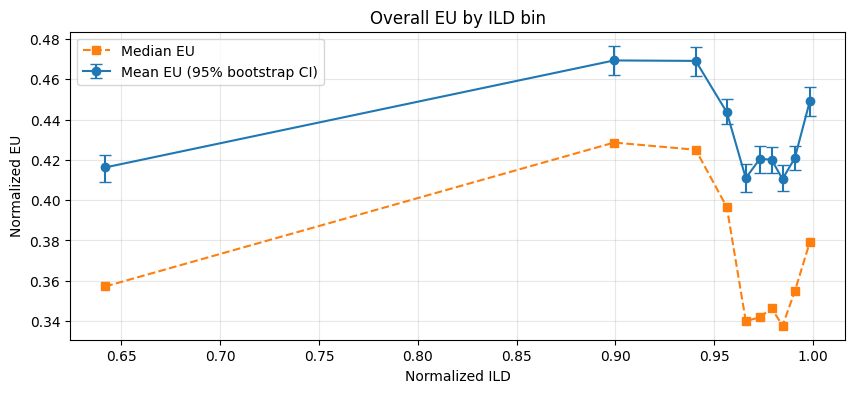

,ild_bin,n,mean_target,median_target,ci_low,ci_high,metric_mean
0,"(-0.001, 0.851]",10070,0.416224,0.357143,0.408817,0.422466,0.641793
1,"(0.851, 0.928]",10069,0.469338,0.428571,0.462112,0.476643,0.899338
2,"(0.928, 0.95]",10073,0.469112,0.425000,0.461541,0.476244,0.940667
3,"(0.95, 0.962]",10068,0.443614,0.396552,0.437783,0.450324,0.956402
4,"(0.962, 0.97]",10069,0.410927,0.340000,0.404261,0.417864,0.966018
5,"(0.97, 0.976]",10065,0.420441,0.341772,0.413661,0.427067,0.973102
6,"(0.976, 0.982]",10069,0.420108,0.346386,0.413289,0.426322,0.979068
7,"(0.982, 0.988]",10069,0.410466,0.337648,0.404313,0.417642,0.984612
8,"(0.988, 0.995]",10069,0.420866,0.354730,0.414881,0.426989,0.990827
9,"(0.995, 1.0]",10069,0.449077,0.379121,0.441861,0.455969,0.998424


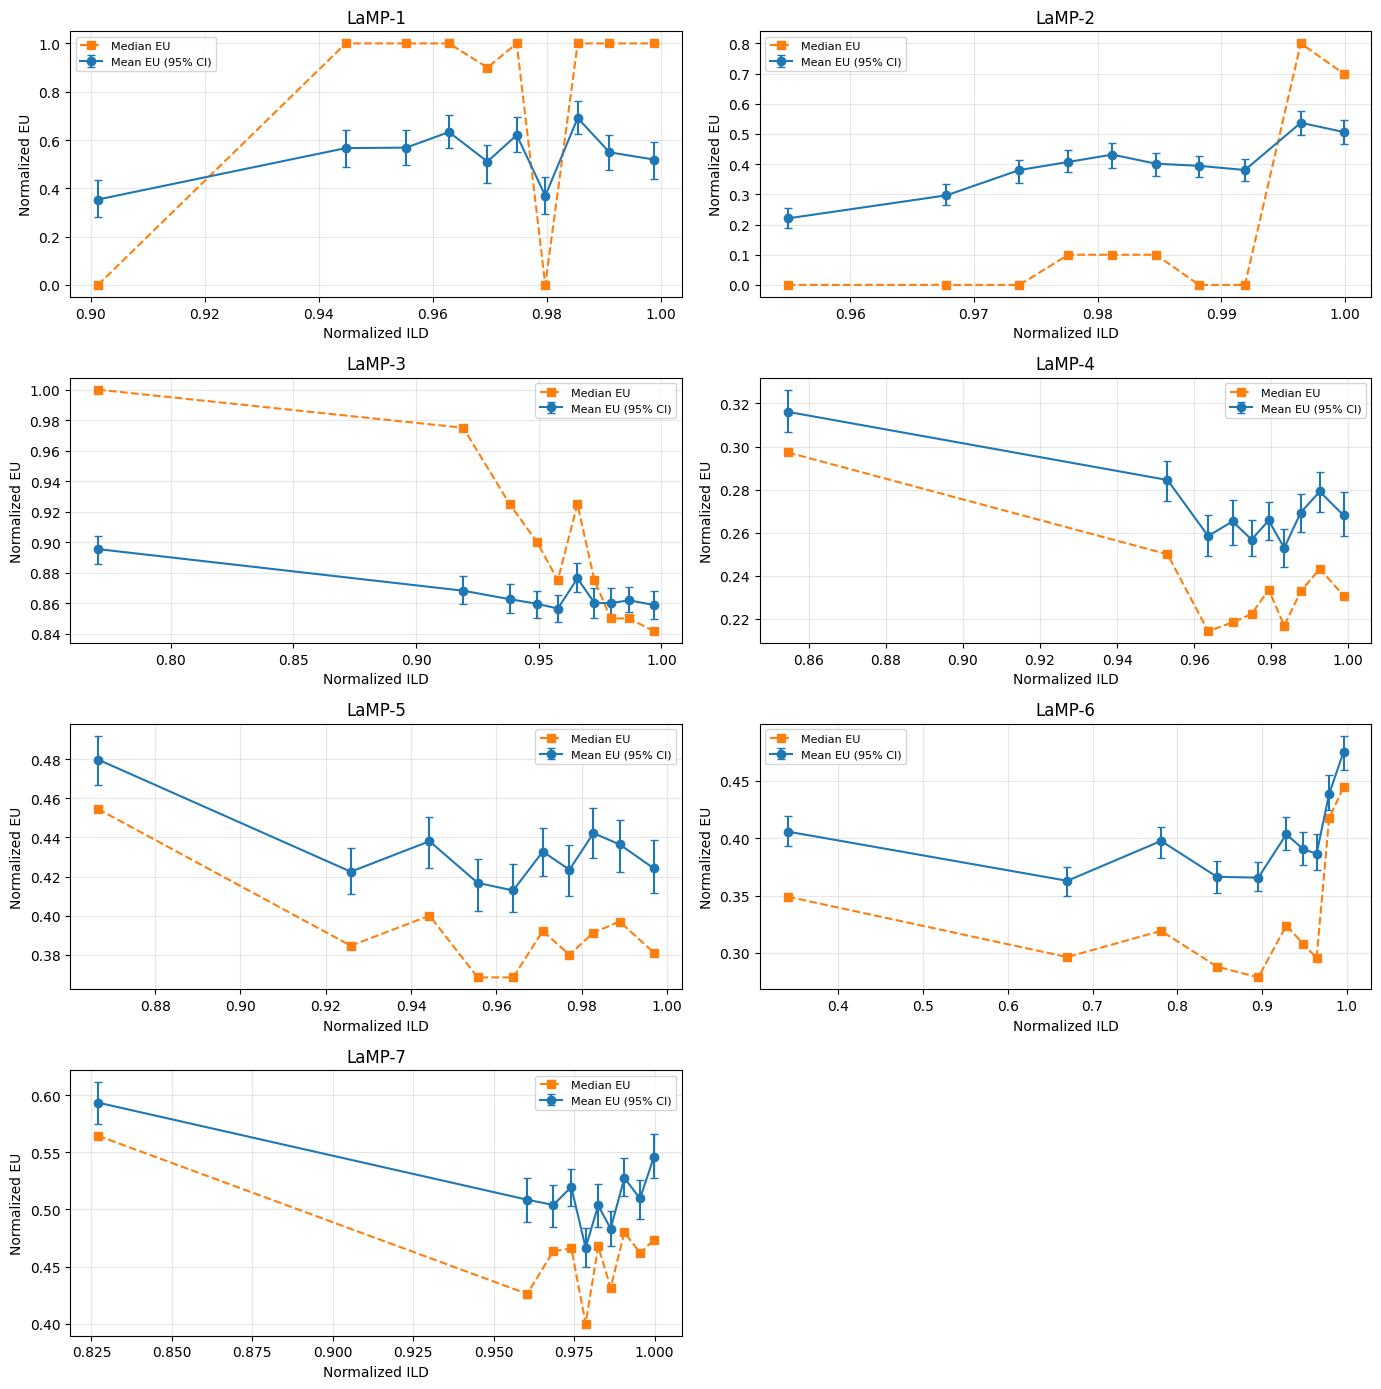

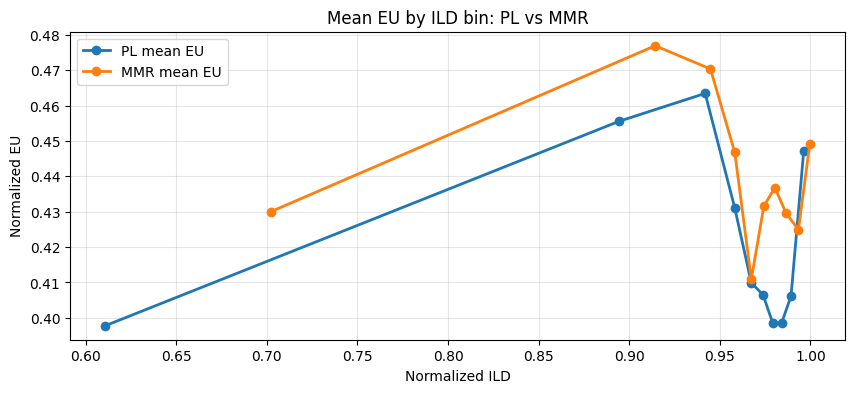

Binned means for PL vs MMR:


,rerank_method,ild_bin,n,metric_mean,mean_target
0,mmr,"(-0.001, 0.877]",5017,0.702097,0.429987
1,mmr,"(0.877, 0.935]",5017,0.914366,0.476944
2,mmr,"(0.935, 0.953]",5021,0.944871,0.470362
3,mmr,"(0.953, 0.963]",5015,0.958291,0.446751
4,mmr,"(0.963, 0.971]",5016,0.967402,0.410880
5,mmr,"(0.971, 0.977]",5017,0.974350,0.431601
6,mmr,"(0.977, 0.983]",5016,0.980450,0.436823
7,mmr,"(0.983, 0.99]",5020,0.986424,0.429719
8,mmr,"(0.99, 0.998]",5014,0.993401,0.424920
9,mmr,"(0.998, 1.0]",5017,0.999696,0.449190


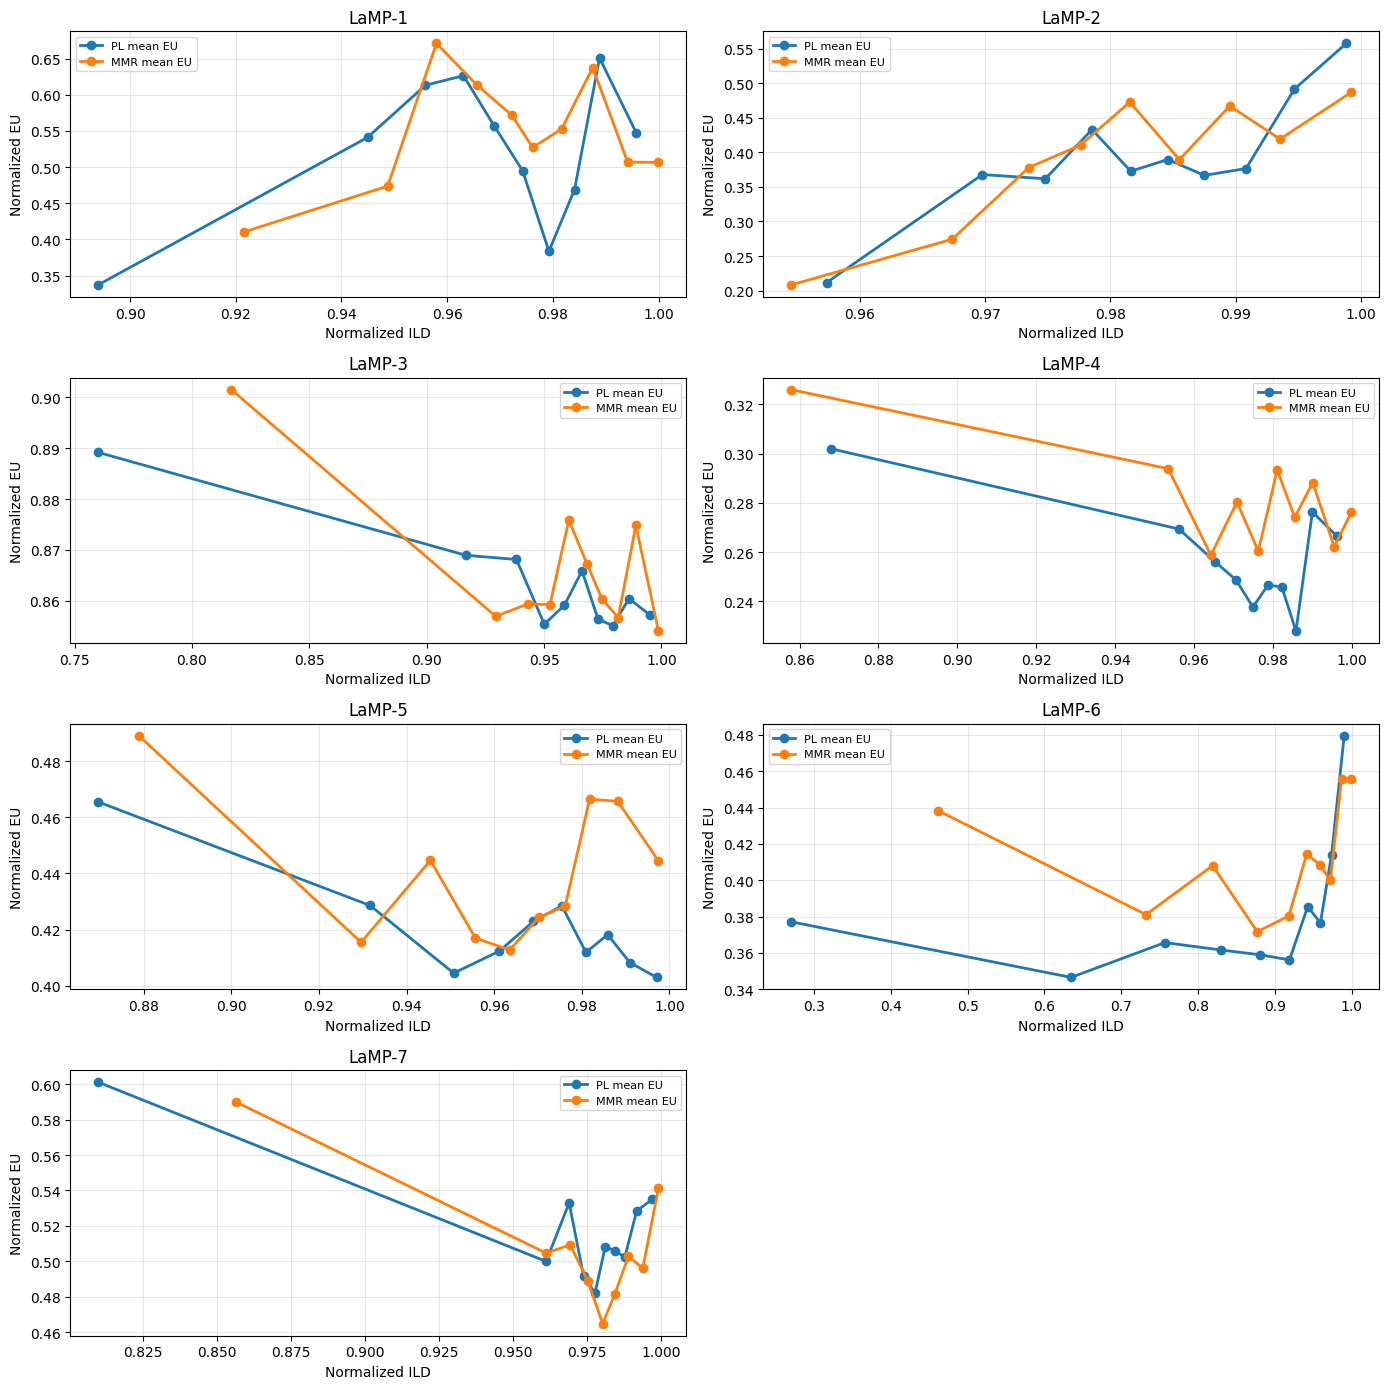

Per-LaMP binned means for PL vs MMR:


,lamp_num,rerank_method,ild_bin,n,metric_mean,mean_target
0,1,mmr,"(0.865, 0.942]",78,0.921545,0.410256
1,1,mmr,"(0.942, 0.953]",76,0.948735,0.473684
2,1,mmr,"(0.953, 0.962]",79,0.957959,0.670886
3,1,mmr,"(0.962, 0.969]",75,0.965604,0.613333
4,1,mmr,"(0.969, 0.974]",77,0.972253,0.571429
...,...,...,...,...,...,...
133,7,pl,"(0.979, 0.983]",438,0.981246,0.508276
134,7,pl,"(0.983, 0.986]",438,0.984581,0.505875
135,7,pl,"(0.986, 0.99]",439,0.987858,0.502334
136,7,pl,"(0.99, 0.994]",437,0.991841,0.528401


Middle-versus-tail summary (overall):


,bucket,count,mean,median,delta_mid_minus_low,delta_mid_minus_high
0,low,33565,0.450821,0.400000,-0.029504,-0.005601
1,mid,33562,0.421317,0.352113,-0.029504,-0.005601
2,high,33563,0.426918,0.357955,-0.029504,-0.005601


Middle-versus-tail summary (by LaMP):


,bucket,count,mean,median,delta_mid_minus_low,delta_mid_minus_high,lamp_num
0,low,514,0.520233,1.000000,0.022257,-0.009275,1
1,mid,506,0.542490,1.000000,0.022257,-0.009275,1
2,high,510,0.551765,1.000000,0.022257,-0.009275,1
3,low,1920,0.309792,0.000000,0.093802,-0.070000,2
4,mid,1920,0.403594,0.100000,0.093802,-0.070000,2
5,high,1920,0.473594,0.200000,0.093802,-0.070000,2
6,low,3113,0.874095,0.975000,-0.009247,0.005915,3
7,mid,3107,0.864848,0.900000,-0.009247,0.005915,3
8,high,3110,0.858934,0.850000,-0.009247,0.005915,3
9,low,8516,0.283066,0.252572,-0.019477,-0.004658,4


In [9]:
# ILD-binned EU exploration

ild_overall = summarize_binned_metric(
    analysis_df,
    metric_col="avg_ild_jaccard_norm",
    target_col="expected_utility_norm",
    bins=CFG.ild_bins,
    label_name="ild_bin",
    bootstrap_rounds=CFG.bootstrap_rounds,
    seed=CFG.random_seed,
).sort_values("metric_mean")

fig, ax = plt.subplots(figsize=(10, 4))
ax.errorbar(
    ild_overall["metric_mean"],
    ild_overall["mean_target"],
    yerr=[ild_overall["mean_target"] - ild_overall["ci_low"], ild_overall["ci_high"] - ild_overall["mean_target"]],
    fmt="o-",
    capsize=4,
    label="Mean EU (95% bootstrap CI)",
)
ax.plot(
    ild_overall["metric_mean"],
    ild_overall["median_target"],
    "s--",
    label="Median EU",
)
ax.set_xlabel("Normalized ILD")
ax.set_ylabel("Normalized EU")
ax.set_title("Overall EU by ILD bin")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

display(ild_overall)

ild_by_lamp = summarize_binned_metric(
    analysis_df,
    metric_col="avg_ild_jaccard_norm",
    target_col="expected_utility_norm",
    bins=CFG.ild_bins,
    group_cols=["lamp_num"],
    label_name="ild_bin",
    bootstrap_rounds=CFG.bootstrap_rounds,
    seed=CFG.random_seed,
).sort_values(["lamp_num", "metric_mean"])

fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharey=False)
axes = axes.flatten()
for idx, lamp_num in enumerate(sorted(analysis_df["lamp_num"].dropna().unique())):
    lamp_df = ild_by_lamp[ild_by_lamp["lamp_num"] == lamp_num]
    ax = axes[idx]
    ax.errorbar(
        lamp_df["metric_mean"],
        lamp_df["mean_target"],
        yerr=[lamp_df["mean_target"] - lamp_df["ci_low"], lamp_df["ci_high"] - lamp_df["mean_target"]],
        fmt="o-",
        capsize=3,
        label="Mean EU (95% CI)",
    )
    ax.plot(
        lamp_df["metric_mean"],
        lamp_df["median_target"],
        "s--",
        label="Median EU",
    )
    ax.set_title(f"LaMP-{int(lamp_num)}")
    ax.set_xlabel("Normalized ILD")
    ax.set_ylabel("Normalized EU")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
for idx in range(len(sorted(analysis_df["lamp_num"].dropna().unique())), len(axes)):
    axes[idx].axis("off")
plt.tight_layout()
plt.show()

# Mean EU per ILD bin split by reranker family (PL vs MMR), overall.
pl_mmr_df = analysis_df[analysis_df["rerank_method"].isin(["pl", "mmr"])].copy()
pl_mmr_binned = summarize_binned_metric(
    pl_mmr_df,
    metric_col="avg_ild_jaccard_norm",
    target_col="expected_utility_norm",
    bins=CFG.ild_bins,
    group_cols=["rerank_method"],
    label_name="ild_bin",
    bootstrap_rounds=CFG.bootstrap_rounds,
    seed=CFG.random_seed,
).sort_values(["rerank_method", "metric_mean"])

fig, ax = plt.subplots(figsize=(10, 4))
for method, color in [("pl", "tab:blue"), ("mmr", "tab:orange")]:
    method_df = pl_mmr_binned[pl_mmr_binned["rerank_method"] == method]
    if method_df.empty:
        continue
    ax.plot(
        method_df["metric_mean"],
        method_df["mean_target"],
        marker="o",
        linestyle="-",
        linewidth=2,
        color=color,
        label=f"{method.upper()} mean EU",
    )
ax.set_xlabel("Normalized ILD")
ax.set_ylabel("Normalized EU")
ax.set_title("Mean EU by ILD bin: PL vs MMR")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

print("Binned means for PL vs MMR:")
display(pl_mmr_binned[["rerank_method", "ild_bin", "n", "metric_mean", "mean_target"]])

# Per-dataset (per-LaMP) PL vs MMR view, matching the faceted style above.
pl_mmr_binned_by_lamp = summarize_binned_metric(
    pl_mmr_df,
    metric_col="avg_ild_jaccard_norm",
    target_col="expected_utility_norm",
    bins=CFG.ild_bins,
    group_cols=["lamp_num", "rerank_method"],
    label_name="ild_bin",
    bootstrap_rounds=CFG.bootstrap_rounds,
    seed=CFG.random_seed,
).sort_values(["lamp_num", "rerank_method", "metric_mean"])

fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharey=False)
axes = axes.flatten()
lamp_values = sorted(pl_mmr_df["lamp_num"].dropna().unique())

for idx, lamp_num in enumerate(lamp_values):
    lamp_df = pl_mmr_binned_by_lamp[pl_mmr_binned_by_lamp["lamp_num"] == lamp_num]
    ax = axes[idx]

    for method, color in [("pl", "tab:blue"), ("mmr", "tab:orange")]:
        method_df = lamp_df[lamp_df["rerank_method"] == method]
        if method_df.empty:
            continue
        ax.plot(
            method_df["metric_mean"],
            method_df["mean_target"],
            marker="o",
            linestyle="-",
            linewidth=2,
            color=color,
            label=f"{method.upper()} mean EU",
        )

    ax.set_title(f"LaMP-{int(lamp_num)}")
    ax.set_xlabel("Normalized ILD")
    ax.set_ylabel("Normalized EU")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

for idx in range(len(lamp_values), len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

print("Per-LaMP binned means for PL vs MMR:")
display(pl_mmr_binned_by_lamp[["lamp_num", "rerank_method", "ild_bin", "n", "metric_mean", "mean_target"]])

middle_tail_overall = middle_vs_tail_summary(
    analysis_df,
    metric_col="avg_ild_jaccard_norm",
    target_col="expected_utility_norm",
)
middle_tail_by_lamp = middle_vs_tail_summary(
    analysis_df,
    metric_col="avg_ild_jaccard_norm",
    target_col="expected_utility_norm",
    group_cols=["lamp_num"],
)

print("Middle-versus-tail summary (overall):")
display(middle_tail_overall)
print("Middle-versus-tail summary (by LaMP):")
display(middle_tail_by_lamp)

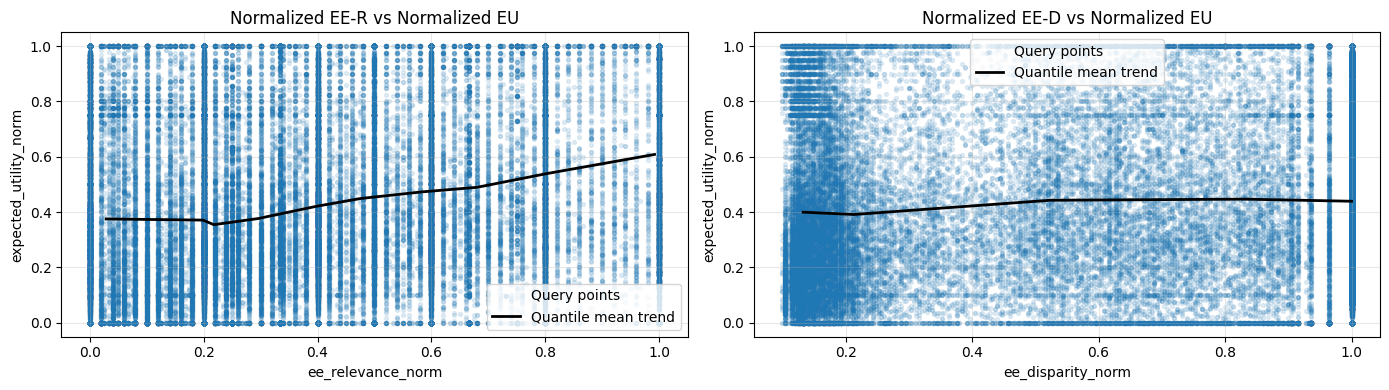

/Users/asimk/Code/Fair-RAG/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Users/asimk/Code/Fair-RAG/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Users/asimk/Code/Fair-RAG/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Users/asimk/Code/Fair-RAG/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Users/asimk/Code/Fair-RAG/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1661: ConstantInputWarning: An input array is constant; the correlat

,scope,metric,spearman_rho,permutation_p_value
0,overall,EE-R,0.201528,0.004975
1,LaMP-1,EE-R,0.035060,0.223881
2,LaMP-2,EE-R,0.184285,0.004975
3,LaMP-3,EE-R,0.465541,0.004975
4,LaMP-4,EE-R,0.365354,0.004975
5,LaMP-5,EE-R,0.040167,0.004975
6,LaMP-6,EE-R,0.232353,0.004975
7,LaMP-7,EE-R,0.230960,0.004975
8,overall,EE-D,0.005612,0.094527
9,LaMP-1,EE-D,0.003967,0.850746


In [10]:
# EE-R and EE-D trend exploration

trend_specs = [
    ("ee_relevance_norm", "Normalized EE-R vs Normalized EU"),
    ("ee_disparity_norm", "Normalized EE-D vs Normalized EU"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (metric_col, title) in zip(axes, trend_specs):
    plot_df = analysis_df.dropna(subset=[metric_col, "expected_utility_norm"])
    ax.scatter(
        plot_df[metric_col],
        plot_df["expected_utility_norm"],
        s=8,
        alpha=0.12,
        label="Query points",
    )
    add_quantile_trend(
        ax,
        plot_df,
        x_col=metric_col,
        y_col="expected_utility_norm",
        bins=12,
        color="black",
        label="Quantile mean trend",
    )
    ax.set_title(title)
    ax.set_xlabel(metric_col)
    ax.set_ylabel("expected_utility_norm")
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

corr_rows = []
for metric_col, label in [("ee_relevance_norm", "EE-R"), ("ee_disparity_norm", "EE-D")]:
    rho, p_value = permutation_spearman(analysis_df[metric_col], analysis_df["expected_utility_norm"])
    corr_rows.append({
        "scope": "overall",
        "metric": label,
        "spearman_rho": rho,
        "permutation_p_value": p_value,
    })
    for lamp_num, lamp_df in analysis_df.groupby("lamp_num", dropna=False):
        rho, p_value = permutation_spearman(lamp_df[metric_col], lamp_df["expected_utility_norm"])
        corr_rows.append({
            "scope": f"LaMP-{int(lamp_num)}",
            "metric": label,
            "spearman_rho": rho,
            "permutation_p_value": p_value,
        })

corr_df = pd.DataFrame(corr_rows)
display(corr_df)

In [11]:
# Tree-like estimator for high-EU prediction

tree_features = ["avg_ild_jaccard_norm", "ee_disparity_norm", "ee_relevance_norm"]
tree_result = evaluate_tree_like_model(analysis_df, tree_features, "target_high_eu")

display(pd.DataFrame([{k: v for k, v in tree_result.items() if k != "model_text"}]))
print("Model structure:")
print(tree_result["model_text"])

# Retrieval AUC evaluation

def compute_ranker_auc_rows(rankers: list[str] | tuple[str, ...]):
    rows = []
    for lamp_num in sorted(analysis_df["lamp_num"].dropna().unique()):
        labels_df = load_relevance_mapping(int(lamp_num), CFG.generator_name)
        qids = sorted(labels_df["qid"].astype(str).unique())
        for ranker in rankers:
            retrieval_scores = load_retrieval_scores(ranker, int(lamp_num), CFG.generator_name)
            aucs = []
            skipped = 0
            for qid in qids:
                q_labels = labels_df[labels_df["qid"].astype(str) == str(qid)].copy()
                if q_labels.empty:
                    continue
                q_score_map = retrieval_scores.get(str(qid), {})
                min_score = min(q_score_map.values()) if q_score_map else -1.0
                fallback = float(min_score) - 1.0
                scores = [q_score_map.get(str(pid), fallback) for pid in q_labels["pid"].astype(str)]
                try:
                    auc = _roc_auc_from_scores(q_labels["relevance_label"].astype(int), scores)
                    aucs.append(float(auc))
                except ValueError:
                    skipped += 1

            ci_low, center, ci_high = bootstrap_ci(aucs, np.mean, rounds=CFG.bootstrap_rounds, seed=CFG.random_seed)
            rows.append({
                "lamp_num": int(lamp_num),
                "ranker": ranker,
                "macro_auc": center,
                "ci_low": ci_low,
                "ci_high": ci_high,
                "n_queries": len(aucs),
                "skipped_queries": skipped,
                "p_value_auc_gt_0.5": _exact_sign_test_greater(aucs, threshold=0.5),
            })

    return pd.DataFrame(rows)


ranker_auc_df = compute_ranker_auc_rows(CFG.rankers)
overall_auc_df = (
    ranker_auc_df.groupby("ranker", dropna=False)["macro_auc"]
    .agg(["mean", "median", "count"])
    .reset_index()
    .rename(columns={"mean": "mean_macro_auc", "median": "median_macro_auc", "count": "n_lamps"})
)

print("Per-LaMP retrieval AUC:")
display(ranker_auc_df.sort_values(["ranker", "lamp_num"]))
print("Overall retrieval AUC summary:")
display(overall_auc_df)

,mode,accuracy,auc,baseline_accuracy,permutation_p_value
0,sklearn_tree,0.588837,0.610187,0.530122,0.004975


Model structure:
|--- ee_relevance_norm <= 0.46
|   |--- ee_relevance_norm <= 0.25
|   |   |--- ee_disparity_norm <= 0.15
|   |   |   |--- class: 0
|   |   |--- ee_disparity_norm >  0.15
|   |   |   |--- class: 0
|   |--- ee_relevance_norm >  0.25
|   |   |--- ee_disparity_norm <= 0.25
|   |   |   |--- class: 0
|   |   |--- ee_disparity_norm >  0.25
|   |   |   |--- class: 1
|--- ee_relevance_norm >  0.46
|   |--- ee_relevance_norm <= 0.80
|   |   |--- avg_ild_jaccard_norm <= 0.93
|   |   |   |--- class: 1
|   |   |--- avg_ild_jaccard_norm >  0.93
|   |   |   |--- class: 1
|   |--- ee_relevance_norm >  0.80
|   |   |--- avg_ild_jaccard_norm <= 0.92
|   |   |   |--- class: 1
|   |   |--- avg_ild_jaccard_norm >  0.92
|   |   |   |--- class: 1

Per-LaMP retrieval AUC:


,lamp_num,ranker,macro_auc,ci_low,ci_high,n_queries,skipped_queries,p_value_auc_gt_0.5
0,1,bm25,0.691167,0.646624,0.737711,51,0,6.057629e-08
3,2,bm25,0.527473,0.498394,0.550102,191,1,7.378859e-03
6,3,bm25,0.489615,0.473475,0.505087,310,1,9.374918e-01
9,4,bm25,0.519741,0.510932,0.528542,824,9,5.593089e-04
12,5,bm25,0.556153,0.547673,0.565268,826,0,5.688477e-32
15,6,bm25,0.562551,0.548306,0.574668,731,29,4.929335e-14
18,7,bm25,0.528423,0.507037,0.550126,352,13,1.634439e-02
2,1,contriever,0.695329,0.658338,0.738153,51,0,9.161814e-09
5,2,contriever,0.588848,0.562674,0.609286,191,1,2.931354e-08
8,3,contriever,0.536831,0.521307,0.552751,310,1,1.863388e-06


Overall retrieval AUC summary:


,ranker,mean_macro_auc,median_macro_auc,n_lamps
0,bm25,0.553589,0.528423,7
1,contriever,0.571518,0.559452,7
2,splade,0.578438,0.566269,7


In [14]:
# Gold retrieval EU stats across datasets (k=5 and k=3)
def _print_gold_eu_stats(df: pd.DataFrame, k_value: int, eu_col: str = "expected_utility") -> None:
    if df.empty:
        print(f"No gold retrieval EU rows found for k={k_value}.")
        return
    if eu_col not in df.columns:
        print(f"Gold rows found for k={k_value}, but {eu_col} is unavailable.")
        return

    by_dataset = (
        df.groupby("lamp_num", dropna=False)[eu_col]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .sort_index()
        .rename(
            columns={
                "count": "n_queries",
                "mean": "eu_mean",
                "median": "eu_median",
                "std": "eu_std",
                "min": "eu_min",
                "max": "eu_max",
            }
        )
    )

    overall = pd.DataFrame(
        [{
            "n_queries": int(df[eu_col].notna().sum()),
            "eu_mean": float(df[eu_col].mean()),
            "eu_median": float(df[eu_col].median()),
            "eu_std": float(df[eu_col].std()),
            "eu_min": float(df[eu_col].min()),
            "eu_max": float(df[eu_col].max()),
        }],
        index=["overall"],
    )

    print(f"Gold retrieval (deterministic) EU stats by dataset for k={k_value}:")
    display(by_dataset)
    print(f"Gold retrieval (deterministic) EU stats overall for k={k_value}:")
    display(overall)


def _collect_gold_rows_for_k(k_value: int) -> pd.DataFrame:
    if k_value == CFG.top_k:
        base_df = normalized_df
        if "expected_utility" not in base_df.columns and "expected_utility" in query_df.columns:
            base_df = base_df.merge(
                query_df[["run_dir", "qid", "expected_utility"]],
                on=["run_dir", "qid"],
                how="left",
            )
        return base_df[base_df["ranker"] == "gold"].copy()

    else:
        run_dirs = find_completed_run_dirs(
            dataset_type=CFG.dataset_type,
            lamp_split_type=CFG.lamp_split_type,
            generator_name=CFG.generator_name,
            top_k=k_value,
            rankers=["gold"],
            rerank_method="deterministic",
        )

    rows = build_query_metric_rows(sorted(set(run_dirs)))
    return pd.DataFrame(rows)


for k in [5, 3]:
    gold_df = _collect_gold_rows_for_k(k)
    _print_gold_eu_stats(gold_df, k_value=k, eu_col="expected_utility")
    print()

Gold retrieval (deterministic) EU stats by dataset for k=5:


,n_queries,eu_mean,eu_median,eu_std,eu_min,eu_max
lamp_num,,,,,,
1,51,0.294118,0.000000,0.460179,0.0,1.000000
2,192,0.375000,0.000000,0.485389,0.0,1.000000
3,311,0.173633,0.000000,0.442222,0.0,2.000000
4,1716,0.075913,0.057971,0.075162,0.0,0.619048
5,826,0.178076,0.133333,0.168149,0.0,1.000000
6,760,0.206854,0.153846,0.217546,0.0,1.000000
7,365,0.246473,0.214286,0.174411,0.0,0.875000


Gold retrieval (deterministic) EU stats overall for k=5:


,n_queries,eu_mean,eu_median,eu_std,eu_min,eu_max
overall,4221,0.157671,0.077922,0.229799,0.0,2.0



Gold retrieval (deterministic) EU stats by dataset for k=3:


,n_queries,eu_mean,eu_median,eu_std,eu_min,eu_max
lamp_num,,,,,,
1,51,0.470588,0.000000,0.504101,0.0,1.000000
2,192,0.687500,1.000000,0.464724,0.0,1.000000
3,311,0.112540,0.000000,0.363944,0.0,2.000000
4,833,0.075369,0.058824,0.071462,0.0,0.558140
5,826,0.174437,0.133333,0.161747,0.0,1.000000
6,760,0.207206,0.164966,0.220840,0.0,1.000000
7,365,0.259494,0.242424,0.174275,0.0,0.909091


Gold retrieval (deterministic) EU stats overall for k=3:


,n_queries,eu_mean,eu_median,eu_std,eu_min,eu_max
overall,3338,0.194745,0.096386,0.265588,0.0,2.0


In [15]:
# Non-normalized EU printout across completed settings

if "expected_utility" not in query_df.columns:
    raise RuntimeError("query_df does not contain expected_utility (raw EU).")

raw_eu_cols = [
    "run_dir",
    "lamp_num",
    "qid",
    "ranker",
    "rerank_method",
    "pl_alpha",
    "mmr_lambda",
    "expected_utility",
]
raw_eu_df = query_df[raw_eu_cols].copy()

# Keep only completed runs already selected for this notebook configuration.
raw_eu_df = raw_eu_df[raw_eu_df["run_dir"].isin(selected_run_dirs)].copy()

print("Raw (non-normalized) expected_utility by setting:")
setting_summary = (
    raw_eu_df
    .groupby(["lamp_num", "ranker", "rerank_method", "pl_alpha", "mmr_lambda"], dropna=False)["expected_utility"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reset_index()
    .sort_values(["lamp_num", "ranker", "rerank_method", "pl_alpha", "mmr_lambda"])
    .rename(
        columns={
            "count": "n_queries",
            "mean": "eu_mean",
            "median": "eu_median",
            "std": "eu_std",
            "min": "eu_min",
            "max": "eu_max",
        }
    )
)
display(setting_summary)

print("\nRaw (non-normalized) expected_utility at query level:")
raw_query_values = raw_eu_df.sort_values(
    ["lamp_num", "ranker", "rerank_method", "pl_alpha", "mmr_lambda", "qid"]
).reset_index(drop=True)
display(raw_query_values)

print("\nRaw (non-normalized) expected_utility by dataset and ranker:")
dataset_ranker_summary = (
    raw_eu_df
    .groupby(["lamp_num", "ranker"], dropna=False)["expected_utility"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reset_index()
    .sort_values(["lamp_num", "ranker"])
    .rename(
        columns={
            "count": "n_queries",
            "mean": "eu_mean",
            "median": "eu_median",
            "std": "eu_std",
            "min": "eu_min",
            "max": "eu_max",
        }
    )
)
display(dataset_ranker_summary)

print()


Raw (non-normalized) expected_utility by setting:


,lamp_num,ranker,rerank_method,pl_alpha,mmr_lambda,n_queries,eu_mean,eu_median,eu_std,eu_min,eu_max
0,1,bm25,deterministic,4,0.55,51,0.117647,0.000000,0.325396,0.000000,1.000000
1,1,bm25,mmr,4,0.25,51,0.078431,0.000000,0.271524,0.000000,1.000000
2,1,bm25,mmr,4,0.45,51,0.078431,0.000000,0.271524,0.000000,1.000000
3,1,bm25,mmr,4,0.55,51,0.078431,0.000000,0.271524,0.000000,1.000000
4,1,bm25,mmr,4,0.65,51,0.078431,0.000000,0.271524,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...
213,7,splade,mmr,4,0.85,365,0.198822,0.133333,0.164179,0.000000,0.888889
214,7,splade,pl,1,0.65,365,0.189000,0.158642,0.121611,0.014014,0.816364
215,7,splade,pl,2,0.65,365,0.188569,0.151801,0.127251,0.003846,0.654545
216,7,splade,pl,4,0.65,365,0.196357,0.146520,0.148671,0.000000,0.855556



Raw (non-normalized) expected_utility at query level:


,run_dir,lamp_num,qid,ranker,rerank_method,pl_alpha,mmr_lambda,expected_utility
0,/Users/asimk/Code/Fair-RAG/experiment_runs/202...,1,0111,bm25,deterministic,4,0.55,1.000000
1,/Users/asimk/Code/Fair-RAG/experiment_runs/202...,1,01110,bm25,deterministic,4,0.55,0.000000
2,/Users/asimk/Code/Fair-RAG/experiment_runs/202...,1,01113,bm25,deterministic,4,0.55,1.000000
3,/Users/asimk/Code/Fair-RAG/experiment_runs/202...,1,0112,bm25,deterministic,4,0.55,0.000000
4,/Users/asimk/Code/Fair-RAG/experiment_runs/202...,1,01132,bm25,deterministic,4,0.55,0.000000
...,...,...,...,...,...,...,...,...
104906,/Users/asimk/Code/Fair-RAG/experiment_runs/202...,7,6199,splade,pl,8,0.65,0.315796
104907,/Users/asimk/Code/Fair-RAG/experiment_runs/202...,7,61990,splade,pl,8,0.65,0.115843
104908,/Users/asimk/Code/Fair-RAG/experiment_runs/202...,7,61993,splade,pl,8,0.65,0.029851
104909,/Users/asimk/Code/Fair-RAG/experiment_runs/202...,7,61994,splade,pl,8,0.65,0.316054



Raw (non-normalized) expected_utility by dataset and ranker:


,lamp_num,ranker,n_queries,eu_mean,eu_median,eu_std,eu_min,eu_max
0,1,bm25,510,0.091176,0.000000,0.277054,0.0,1.000000
1,1,contriever,510,0.092353,0.000000,0.278080,0.0,1.000000
2,1,gold,51,0.294118,0.000000,0.460179,0.0,1.000000
3,1,splade,510,0.136667,0.000000,0.332887,0.0,1.000000
4,2,bm25,1920,0.127344,0.000000,0.307823,0.0,1.000000
5,2,contriever,1920,0.170000,0.000000,0.347950,0.0,1.000000
6,2,gold,192,0.375000,0.000000,0.485389,0.0,1.000000
7,2,splade,1920,0.139635,0.000000,0.319077,0.0,1.000000
8,3,bm25,3110,0.556559,0.400000,0.590147,0.0,4.000000
9,3,contriever,3110,0.569068,0.500000,0.595584,0.0,4.000000


## Interpretation Notes

Use this notebook in an exploratory way first.

Suggested reading order:
1. Check coverage and null-rate tables before trusting any plots
2. Inspect the ILD-binned EU curves for a possible middle-range sweet spot
3. Compare the EE-R and EE-D trend summaries to see whether the signal is directionally stable across LaMP tasks
4. Read the tree output only after the plots, since the tree is meant to test whether the metrics carry usable predictive signal beyond guessing
5. Interpret retrieval AUC separately from reranking utility: AUC>0.5 here means the retriever is better than random as a binary relevance scorer, not that it necessarily maximizes final RAG utility

If the exploratory plots look promising, the next step is to tighten the notebook with targeted significance checks on the specific patterns that actually appear.